In [590]:
from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib
import math
import seaborn as sns
import pandas as pd
from sympy import *
from sympy import Symbol, solveset, S, erf, log, sqrt
init_printing(use_unicode=True)

import scipy.optimize as optimize

In [591]:
# Read in the results

#G_strategy_dataset = pd.read_csv('G_strategy_results_jun3.csv')
results_dataset = pd.read_csv('/Users/benjaminlaufer/Python Projects/ai-regulation-games/multi_dimension_with_bargaining_data_foruse_two.csv')
#results_dataset = pd.read_csv('results_with_backfiring_all_backup.csv')
last_98_results = pd.read_csv('results_with_backfiring_all_backup_last98.csv')
#lastlast_196_results = pd.read_csv('results_with_backfiring_all_backup_lastlast19698.csv')
# Concatenate the last 98 results with the results_dataset
#results_dataset = pd.concat([results_dataset, last_98_results], ignore_index=True)

# Define the utilitarian, nash and egalitarian utilities
results_dataset['U_util'] = results_dataset['U_G'] + results_dataset['U_D']
results_dataset['U_nash'] = [results_dataset.loc[i,'U_G']*results_dataset.loc[i,'U_D'] if (results_dataset.loc[i,'U_G']>0) and (results_dataset.loc[i,'U_D']>0) else -0.1 for i in range(len(results_dataset))]
results_dataset['U_egal'] = np.minimum(results_dataset['U_G'], results_dataset['U_D'])

results_dataset['theta'] = np.round(results_dataset['theta'], 4)
results_dataset['thetaG'] = np.round(results_dataset['thetaG'], 4)

results_dataset_util = results_dataset.groupby(['theta','thetaG']).apply(lambda x: x.loc[x['U_util'].idxmax()]).reset_index(drop=True)
results_dataset_egal = results_dataset.groupby(['theta','thetaG']).apply(lambda x: x.loc[x['U_egal'].idxmax()]).reset_index(drop=True)
results_dataset_nash = results_dataset.groupby(['theta','thetaG']).apply(lambda x: x.loc[x['U_nash'].idxmax()]).reset_index(drop=True)

no_gt_dataset = results_dataset[results_dataset['thetaG']==0].copy().reset_index(drop=True)






/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_81622/892530692.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results_dataset_util = results_dataset.groupby(['theta','thetaG']).apply(lambda x: x.loc[x['U_util'].idxmax()]).reset_index(drop=True)
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_81622/892530692.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results_dataset_ega

In [592]:
results_dataset

,Unnamed: 0,C0,C1,r,delta,theta,thetaG,alpha_0,alpha_1,beta_1,U_G,U_D,Gstrategy,Dstrategy,beta_0,U_util,U_nash,U_egal
0,0,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.010000,0.0,0.0,0.005000,0.5,0.5,0.009950,0.499950,unconstrained,unconstrained,0.005000,0.509900,0.004975,0.009950
1,1,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.020103,0.0,0.0,0.010052,0.5,0.5,0.019901,0.499798,unconstrained,unconstrained,0.010052,0.519699,0.009946,0.019901
2,2,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.030206,0.0,0.0,0.015103,0.5,0.5,0.029750,0.499544,unconstrained,unconstrained,0.015103,0.529294,0.014861,0.029750
3,3,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.040309,0.0,0.0,0.020155,0.5,0.5,0.039497,0.499188,unconstrained,unconstrained,0.020155,0.538684,0.019716,0.039497
4,4,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.050412,0.0,0.0,0.025206,0.5,0.5,0.049142,0.498729,unconstrained,unconstrained,0.025206,0.547871,0.024508,0.049142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49681,49681,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.949588,2.5,1.2,-0.100000,-0.1,-0.1,-0.100000,-0.100000,abstain,abstain,-0.100000,-0.200000,-0.100000,-0.100000
49682,49682,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.959691,2.5,1.2,-0.100000,-0.1,-0.1,-0.100000,-0.100000,abstain,abstain,-0.100000,-0.200000,-0.100000,-0.100000
49683,49683,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.969794,2.5,1.2,-0.100000,-0.1,-0.1,-0.100000,-0.100000,abstain,abstain,-0.100000,-0.200000,-0.100000,-0.100000
49684,49684,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.979897,2.5,1.2,-0.100000,-0.1,-0.1,-0.100000,-0.100000,abstain,abstain,-0.100000,-0.200000,-0.100000,-0.100000


/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_81622/1986475691.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  no_gt_dataset_util = no_gt_dataset.groupby('theta').apply(lambda x: x.loc[x['U_util'].idxmax()])
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_81622/1986475691.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  no_gt_dataset_egal = no_gt_dataset.groupby('theta').apply

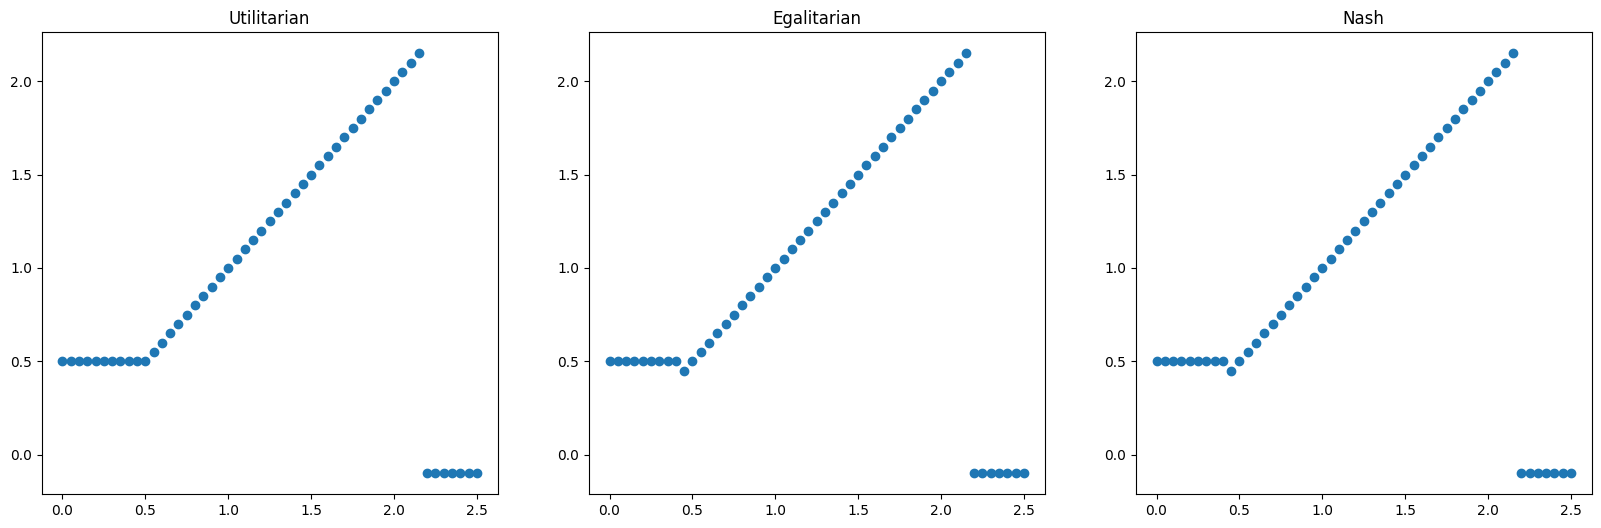

In [593]:
# Group by the value of theta and keep the row that has the highest U_util
no_gt_dataset_util = no_gt_dataset.groupby('theta').apply(lambda x: x.loc[x['U_util'].idxmax()])
no_gt_dataset_egal = no_gt_dataset.groupby('theta').apply(lambda x: x.loc[x['U_egal'].idxmax()])
no_gt_dataset_nash = no_gt_dataset.groupby('theta').apply(lambda x: x.loc[x['U_nash'].idxmax()])
# Plot the results
fig, ax = plt.subplots(1,3,figsize=(20, 6))
ax[0].scatter(no_gt_dataset_util['theta'], no_gt_dataset_util['beta_1'])
ax[1].scatter(no_gt_dataset_egal['theta'], no_gt_dataset_egal['beta_1'])
ax[2].scatter(no_gt_dataset_nash['theta'], no_gt_dataset_nash['beta_1'])
ax[0].set_title('Utilitarian')
ax[1].set_title('Egalitarian')
ax[2].set_title('Nash')
plt.show()


In [564]:
results_dataset_util.pivot_table(values='beta_1', index='theta', columns='thetaG', aggfunc='mean', dropna=False, fill_value=0)

thetaG,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2
theta,,,,,,,,,,,,,
0.00,0.50,0.00,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000
0.05,0.50,0.00,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000
0.10,0.50,0.50,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000
0.15,0.50,0.50,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000
0.20,0.50,0.50,0.50,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000
0.25,0.50,0.50,0.50,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000
0.30,0.50,0.50,0.50,0.633351,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000
0.35,0.50,0.50,0.50,0.633351,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000
0.40,0.50,0.50,0.50,0.633351,0.733351,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000


HI
0.5


/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_81622/788270034.py:57: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax[2].legend(loc='lower right')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_81622/788270034.py:65: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax[1].legend(loc='lower right')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_81622/788270034.py:73: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax[0].legend(loc='lower right')


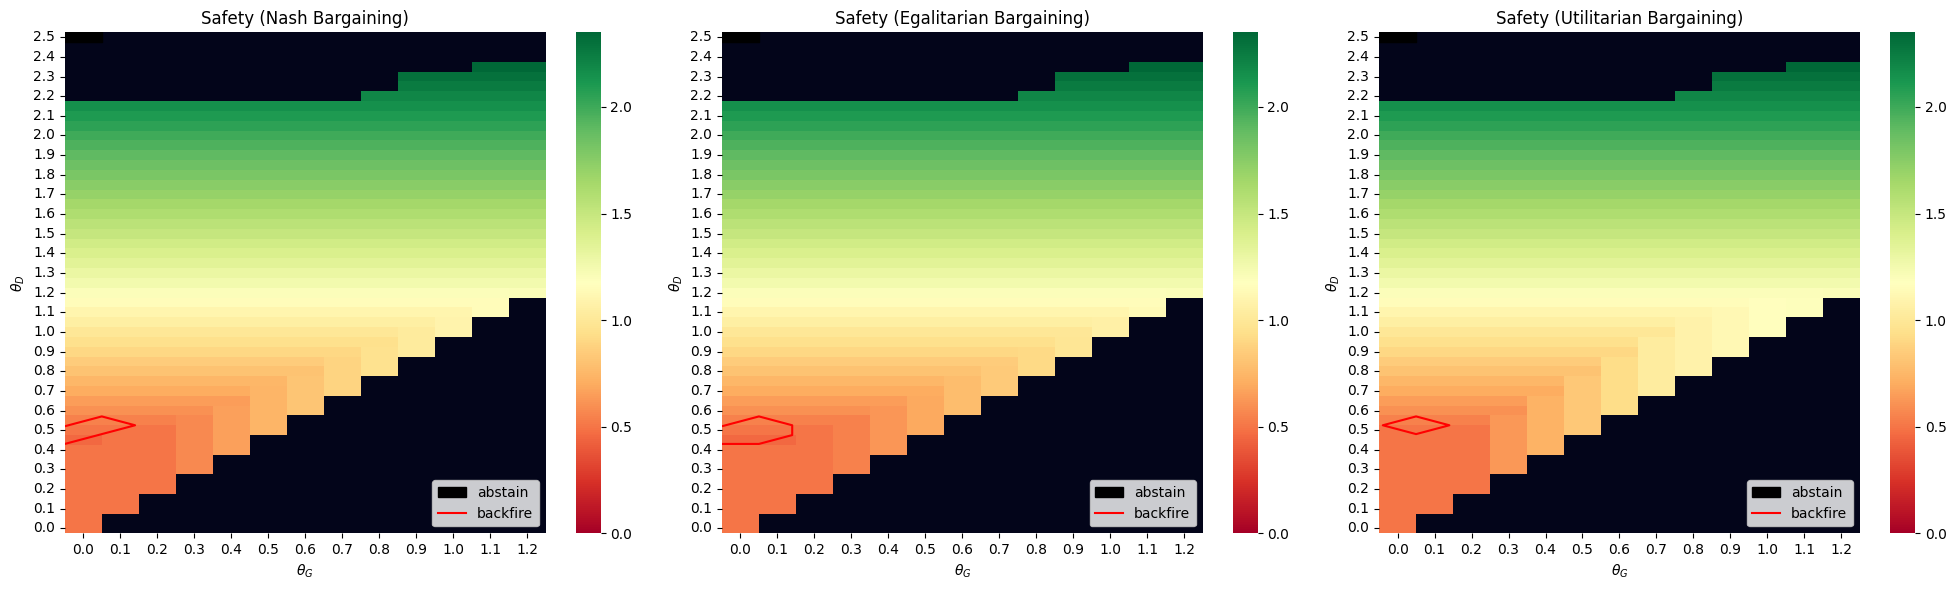

In [565]:
# using the results_dataset, heatmap the beta_1 values for the utilitarian, nash and egalitarian utilities
fig, ax = plt.subplots(1,3,figsize=(20, 6))

# Heatmap: The y axis should be the theta values. The x axis should be the thetaG values. The colors should be the beta_1 values.
# Create pivot tables for heatmaps

print("HI")

util_pivot = results_dataset_util.pivot_table(values='beta_1', index='theta', columns='thetaG', aggfunc='mean')
egal_pivot = results_dataset_egal.pivot_table(values='beta_1', index='theta', columns='thetaG', aggfunc='mean')
nash_pivot = results_dataset_nash.pivot_table(values='beta_1', index='theta', columns='thetaG', aggfunc='mean')

# What is the value of beta_1 at theta = 0 and thetaG = 0 for the utilitarian, nash and egalitarian utilities
util_beta_1_noreg = util_pivot.iloc[0,0]#results_dataset[(results_dataset['theta'] == 0) & (results_dataset['thetaG'] == 0)]['beta_1'].values[0]
egal_beta_1_noreg = egal_pivot.iloc[0,0]#results_dataset[(results_dataset['theta'] == 0) & (results_dataset['thetaG'] == 0)]['beta_1'].values[0]
nash_beta_1_noreg = nash_pivot.iloc[0,0]#results_dataset[(results_dataset['theta'] == 0) & (results_dataset['thetaG'] == 0)]['beta_1'].values[0]
print(util_beta_1_noreg)

# Reverse the y axis for the heatmaps
util_pivot = util_pivot.iloc[::-1]
egal_pivot = egal_pivot.iloc[::-1]
nash_pivot = nash_pivot.iloc[::-1]

sns.heatmap(nash_pivot, ax=ax[0], cmap='RdYlGn', vmin=0)
ax[0].set_title('Safety (Nash Bargaining)')
sns.heatmap(egal_pivot, ax=ax[1], cmap='RdYlGn', vmin=0)
ax[1].set_title('Safety (Egalitarian Bargaining)')
sns.heatmap(util_pivot , ax=ax[2], cmap='RdYlGn', vmin=0)
ax[2].set_title('Safety (Utilitarian Bargaining)')

# Now, plot a contour map to show where beta_1 is lower than the noreg values
eps = 0#0.000001
util_pivot_backfire = util_pivot.copy()
util_pivot_backfire[(util_pivot < util_beta_1_noreg-eps)&(util_pivot>=0)]=1
util_pivot_backfire[(util_pivot >= util_beta_1_noreg-eps)|(util_pivot<0)]=0
util_pivot_abstain = util_pivot.copy()
util_pivot_abstain[(util_pivot<0)|(np.isnan(util_pivot))]=1
util_pivot_abstain[util_pivot>0]=np.nan
egal_pivot_backfire = egal_pivot.copy()
egal_pivot_backfire[(egal_pivot < egal_beta_1_noreg-eps) & (egal_pivot >= 0)]=1
egal_pivot_backfire[(egal_pivot >= egal_beta_1_noreg-eps) | (egal_pivot < 0)]=0
egal_pivot_abstain = egal_pivot.copy()
egal_pivot_abstain[(egal_pivot<0)|(np.isnan(egal_pivot))]=1
egal_pivot_abstain[egal_pivot>0]=np.nan
nash_pivot_backfire = nash_pivot.copy()
nash_pivot_backfire[(nash_pivot < nash_beta_1_noreg-eps) & (nash_pivot >= 0)]=1
nash_pivot_backfire[(nash_pivot >= nash_beta_1_noreg-eps) | (nash_pivot < 0)]=0
nash_pivot_abstain = nash_pivot.copy()
nash_pivot_abstain[(nash_pivot<0)|(np.isnan(nash_pivot))]=1
nash_pivot_abstain[nash_pivot>0]=np.nan

#sns.heatmap(util_pivot_backfire, ax=ax[0])
ax[2].contour(util_pivot_backfire, levels=[0.1,1], colors='red', zorder=100)
sns.heatmap(util_pivot_abstain, ax=ax[2], cbar=False,label='abstain')
ax[2].fill([0,0,1,1],[0,1,1,0],color='black', label='abstain')
ax[2].plot([],[],color='red', label='backfire')
ax[2].legend(loc='lower right')
ax[2].set_xlabel('$\\theta_G$')
ax[2].set_ylabel('$\\theta_D$')

ax[1].contour(egal_pivot_backfire, levels=[0.1,1], colors='red', zorder=100)
sns.heatmap(egal_pivot_abstain, ax=ax[1], cbar=False,label='abstain')
ax[1].fill([0,0,1,1],[0,1,1,0],color='black', label='abstain')
ax[1].plot([],[],color='red', label='backfire')
ax[1].legend(loc='lower right')
ax[1].set_xlabel('$\\theta_G$')
ax[1].set_ylabel('$\\theta_D$')

ax[0].contour(nash_pivot_backfire, levels=[0.1,1], colors='red', zorder=100)
sns.heatmap(nash_pivot_abstain, ax=ax[0], cbar=False,label='abstain')
ax[0].fill([0,0,1,1],[0,1,1,0],color='black', label='abstain')
ax[0].plot([],[],color='red', label='backfire')
ax[0].legend(loc='lower right')
ax[0].set_xlabel('$\\theta_G$')
ax[0].set_ylabel('$\\theta_D$')

#ax[1].contourf(egal_pivot_backfire, levels=[0.1,1], colors='black', zorder=100)
#ax[2].contour(nash_pivot_backfire, colors='black')

plt.tight_layout()

#plt.savefig('bargaining_heatmaps_june4.png', bbox_inches='tight', dpi=300)

plt.show()


HI


/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_81622/2963701691.py:58: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax[2].legend(loc='lower right')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_81622/2963701691.py:66: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax[0].legend(loc='lower right')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_81622/2963701691.py:74: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax[1].legend(loc='lower right')


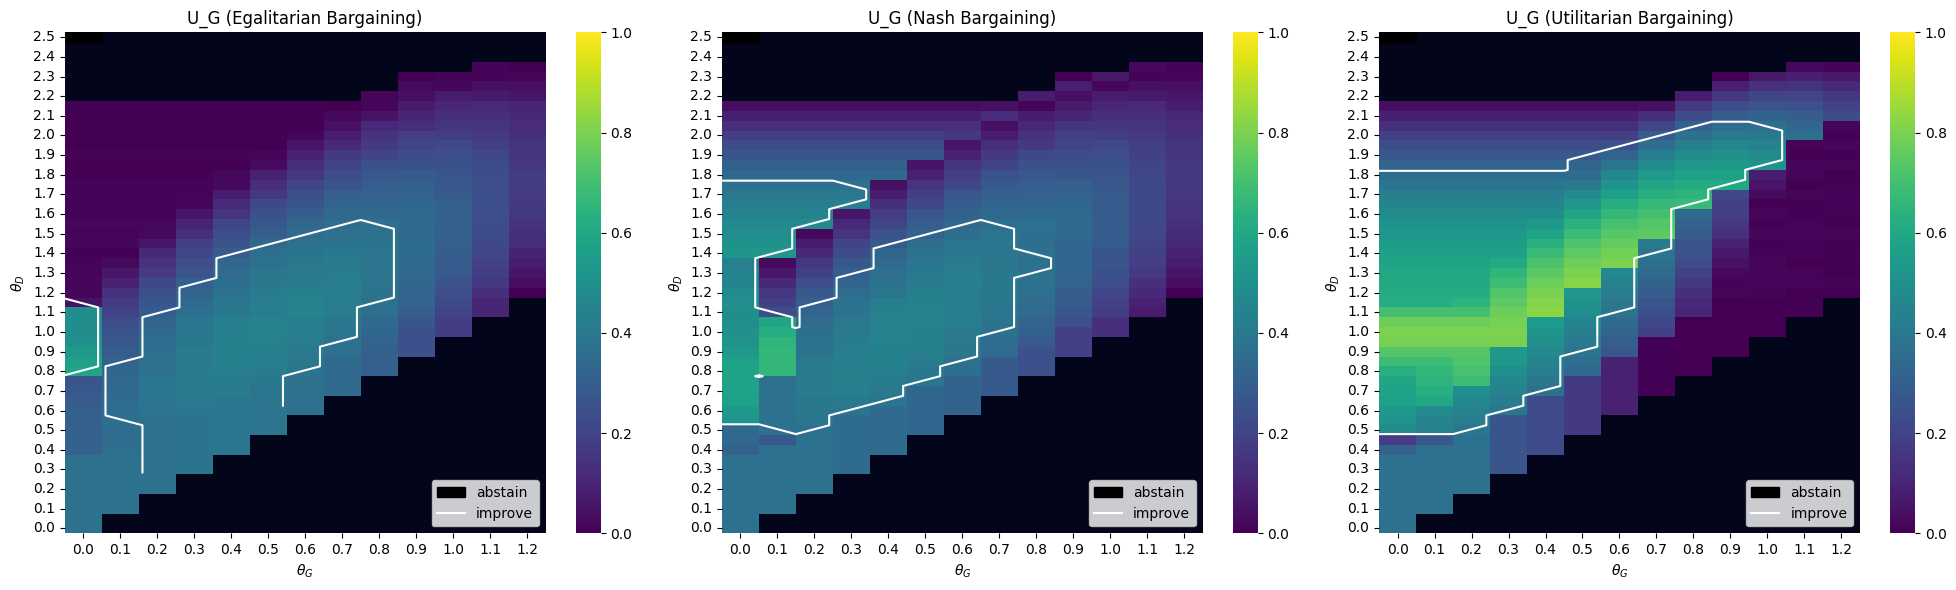

In [566]:
# Now produce exactly the same plots as above, but for the U_G

# using the results_dataset, heatmap the beta_1 values for the utilitarian, nash and egalitarian utilities
fig, ax = plt.subplots(1,3,figsize=(20, 6))

# Heatmap: The y axis should be the theta values. The x axis should be the thetaG values. The colors should be the beta_1 values.
# Create pivot tables for heatmaps

print("HI")

util_pivot = results_dataset_util.pivot_table(values='U_G', index='theta', columns='thetaG', aggfunc='mean')
egal_pivot = results_dataset_egal.pivot_table(values='U_G', index='theta', columns='thetaG', aggfunc='mean')
nash_pivot = results_dataset_nash.pivot_table(values='U_G', index='theta', columns='thetaG', aggfunc='mean')

# What is the value of beta_1 at theta = 0 and thetaG = 0 for the utilitarian, nash and egalitarian utilities
util_U_noreg = util_pivot.iloc[0,0]#results_dataset[(results_dataset['theta'] == 0) & (results_dataset['thetaG'] == 0)]['beta_1'].values[0]
egal_U_noreg = egal_pivot.iloc[0,0]#results_dataset[(results_dataset['theta'] == 0) & (results_dataset['thetaG'] == 0)]['beta_1'].values[0]
nash_U_noreg = nash_pivot.iloc[0,0]#results_dataset[(results_dataset['theta'] == 0) & (results_dataset['thetaG'] == 0)]['beta_1'].values[0]

# Reverse the y axis for the heatmaps
util_pivot = util_pivot.iloc[::-1]
egal_pivot = egal_pivot.iloc[::-1]
nash_pivot = nash_pivot.iloc[::-1]

#Colorbar kwargs should have vmin=0 and vmax=1
sns.heatmap(egal_pivot, ax=ax[0], cmap='viridis', vmin=0, vmax=1)
ax[0].set_title('U_G (Egalitarian Bargaining)')
sns.heatmap(nash_pivot, ax=ax[1], cmap='viridis', vmin=0, vmax=1)
ax[1].set_title('U_G (Nash Bargaining)')
sns.heatmap(util_pivot , ax=ax[2], cmap='viridis', vmin=0, vmax=1)
ax[2].set_title('U_G (Utilitarian Bargaining)')

# Now, plot a contour map to show where beta_1 is lower than the noreg values
util_pivot_improve   = util_pivot.copy()
util_pivot_improve[(util_pivot > util_U_noreg)]=1
util_pivot_improve[(util_pivot <= util_U_noreg)]=0
util_pivot_abstain = util_pivot.copy()
util_pivot_abstain[(util_pivot<0)|(np.isnan(util_pivot))]=1
util_pivot_abstain[util_pivot>0]=np.nan
egal_pivot_improve = egal_pivot.copy()
egal_pivot_improve[(egal_pivot > egal_U_noreg)]=1
egal_pivot_improve[(egal_pivot <= egal_U_noreg)]=0
egal_pivot_abstain = egal_pivot.copy()
egal_pivot_abstain[(egal_pivot<0)|(np.isnan(egal_pivot))]=1
egal_pivot_abstain[egal_pivot>0]=np.nan
nash_pivot_improve = nash_pivot.copy()
nash_pivot_improve[(nash_pivot > nash_U_noreg)]=1
nash_pivot_improve[(nash_pivot <= nash_U_noreg)]=0
nash_pivot_abstain = nash_pivot.copy()
nash_pivot_abstain[(nash_pivot<0)|(np.isnan(nash_pivot))]=1
nash_pivot_abstain[nash_pivot>0]=np.nan

#sns.heatmap(util_pivot_backfire, ax=ax[0])
ax[2].contour(util_pivot_improve, levels=[0.1,1], colors='white', zorder=100)
sns.heatmap(util_pivot_abstain, ax=ax[2], cbar=False,label='abstain')
ax[2].fill([0,0,1,1],[0,1,1,0],color='black', label='abstain')
ax[2].plot([],[],color='white', label='improve')
ax[2].legend(loc='lower right')
ax[2].set_xlabel('$\\theta_G$')
ax[2].set_ylabel('$\\theta_D$')

ax[0].contour(egal_pivot_improve, levels=[0.1,1], colors='white', zorder=100)
sns.heatmap(egal_pivot_abstain, ax=ax[0], cbar=False,label='abstain')
ax[0].fill([0,0,1,1],[0,1,1,0],color='black', label='abstain')
ax[0].plot([],[],color='white', label='improve')
ax[0].legend(loc='lower right')
ax[0].set_xlabel('$\\theta_G$')
ax[0].set_ylabel('$\\theta_D$')

ax[1].contour(nash_pivot_improve, levels=[0.1,1], colors='white', zorder=100)
sns.heatmap(nash_pivot_abstain, ax=ax[1], cbar=False,label='abstain')
ax[1].fill([0,0,1,1],[0,1,1,0],color='black', label='abstain')
ax[1].plot([],[],color='white', label='improve')
ax[1].legend(loc='lower right')
ax[1].set_xlabel('$\\theta_G$')
ax[1].set_ylabel('$\\theta_D$')

#ax[1].contourf(egal_pivot_backfire, levels=[0.1,1], colors='black', zorder=100)
#ax[2].contour(nash_pivot_backfire, colors='black')

plt.tight_layout()

#plt.savefig('bargaining_heatmaps_UG_june4.png', bbox_inches='tight', dpi=300)

plt.show()

HI


/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_81622/266862140.py:57: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax[2].legend(loc='lower right')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_81622/266862140.py:65: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax[0].legend(loc='lower right')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_81622/266862140.py:73: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax[1].legend(loc='lower right')


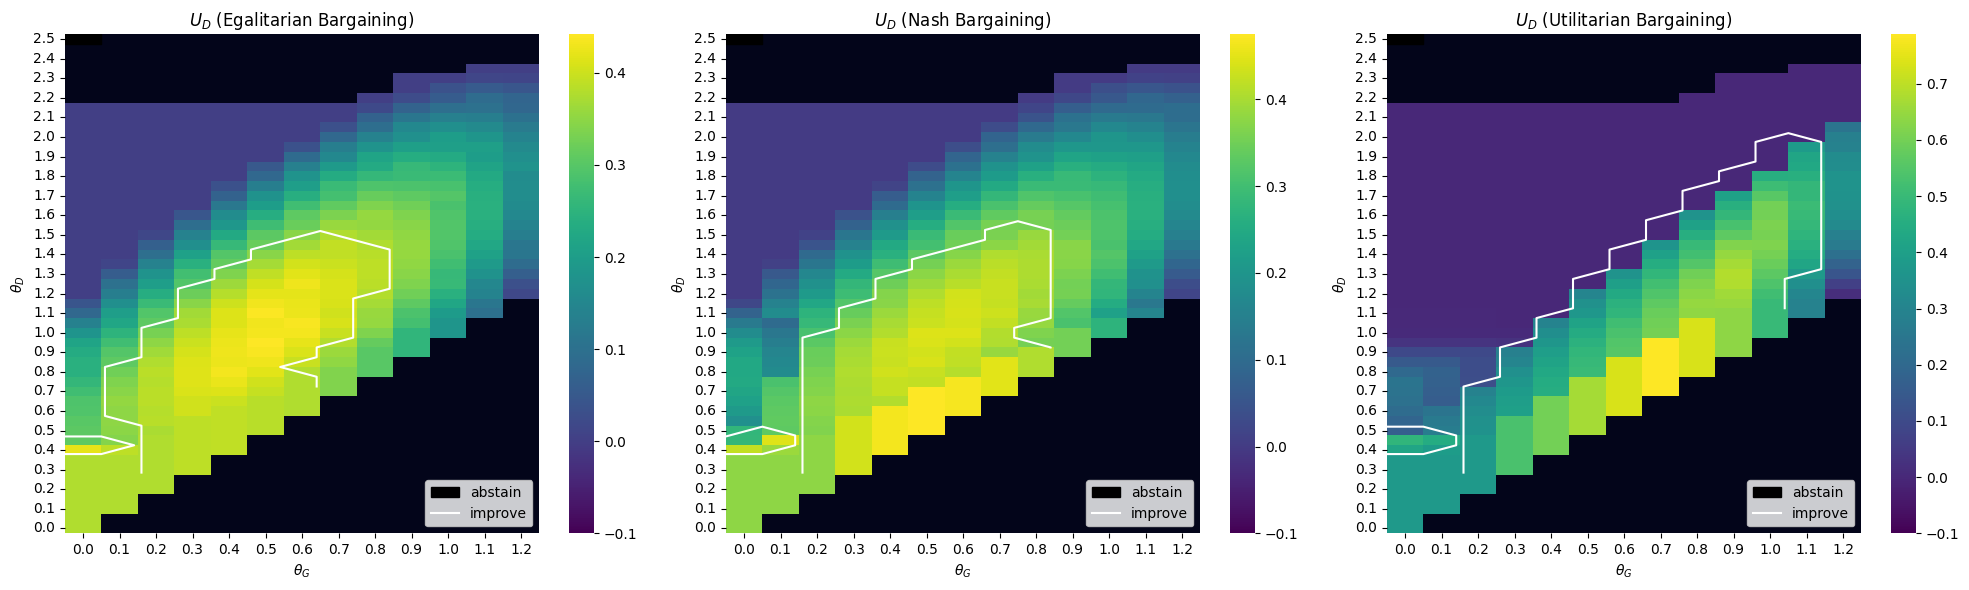

In [567]:
# Now produce exactly the same plots as above, but for the U_G

# using the results_dataset, heatmap the beta_1 values for the utilitarian, nash and egalitarian utilities
fig, ax = plt.subplots(1,3,figsize=(20, 6))

# Heatmap: The y axis should be the theta values. The x axis should be the thetaG values. The colors should be the beta_1 values.
# Create pivot tables for heatmaps

print("HI")

util_pivot = results_dataset_util.pivot_table(values='U_D', index='theta', columns='thetaG', aggfunc='mean')
egal_pivot = results_dataset_egal.pivot_table(values='U_D', index='theta', columns='thetaG', aggfunc='mean')
nash_pivot = results_dataset_nash.pivot_table(values='U_D', index='theta', columns='thetaG', aggfunc='mean')

# What is the value of beta_1 at theta = 0 and thetaG = 0 for the utilitarian, nash and egalitarian utilities
util_U_noreg = util_pivot.iloc[0,0]#results_dataset[(results_dataset['theta'] == 0) & (results_dataset['thetaG'] == 0)]['beta_1'].values[0]
egal_U_noreg = egal_pivot.iloc[0,0]#results_dataset[(results_dataset['theta'] == 0) & (results_dataset['thetaG'] == 0)]['beta_1'].values[0]
nash_U_noreg = nash_pivot.iloc[0,0]#results_dataset[(results_dataset['theta'] == 0) & (results_dataset['thetaG'] == 0)]['beta_1'].values[0]

# Reverse the y axis for the heatmaps
util_pivot = util_pivot.iloc[::-1]
egal_pivot = egal_pivot.iloc[::-1]
nash_pivot = nash_pivot.iloc[::-1]

sns.heatmap(egal_pivot, ax=ax[0], cmap='viridis')
ax[0].set_title('$U_D$ (Egalitarian Bargaining)')
sns.heatmap(nash_pivot, ax=ax[1], cmap='viridis')
ax[1].set_title('$U_D$ (Nash Bargaining)')
sns.heatmap(util_pivot , ax=ax[2], cmap='viridis')
ax[2].set_title('$U_D$ (Utilitarian Bargaining)')

# Now, plot a contour map to show where beta_1 is lower than the noreg values
util_pivot_improve = util_pivot.copy()
util_pivot_improve[(util_pivot > util_U_noreg)]=1
util_pivot_improve[(util_pivot <= util_U_noreg)]=0
util_pivot_abstain = util_pivot.copy()
util_pivot_abstain[(util_pivot<0)|(np.isnan(util_pivot))]=1
util_pivot_abstain[util_pivot>0]=np.nan
egal_pivot_improve = egal_pivot.copy()
egal_pivot_improve[(egal_pivot > egal_U_noreg)]=1
egal_pivot_improve[(egal_pivot <= egal_U_noreg)]=0
egal_pivot_abstain = egal_pivot.copy()
egal_pivot_abstain[(egal_pivot<0)|(np.isnan(egal_pivot))]=1
egal_pivot_abstain[egal_pivot>0]=np.nan
nash_pivot_improve = nash_pivot.copy()
nash_pivot_improve[(nash_pivot > nash_U_noreg)]=1
nash_pivot_improve[(nash_pivot <= nash_U_noreg)]=0
nash_pivot_abstain = nash_pivot.copy()
nash_pivot_abstain[(nash_pivot<0)|(np.isnan(nash_pivot))]=1
nash_pivot_abstain[nash_pivot>0]=np.nan

#sns.heatmap(util_pivot_backfire, ax=ax[0])
ax[2].contour(util_pivot_improve, levels=[0.1,1], colors='white', zorder=100)
sns.heatmap(util_pivot_abstain, ax=ax[2], cbar=False,label='abstain')
ax[2].fill([0,0,1,1],[0,1,1,0],color='black', label='abstain')
ax[2].plot([],[],color='white', label='improve')
ax[2].legend(loc='lower right')
ax[2].set_xlabel('$\\theta_G$')
ax[2].set_ylabel('$\\theta_D$')

ax[0].contour(egal_pivot_improve, levels=[0.1,1], colors='white', zorder=100)
sns.heatmap(egal_pivot_abstain, ax=ax[0], cbar=False,label='abstain')
ax[0].fill([0,0,1,1],[0,1,1,0],color='black', label='abstain')
ax[0].plot([],[],color='white', label='improve')
ax[0].legend(loc='lower right')
ax[0].set_xlabel('$\\theta_G$')
ax[0].set_ylabel('$\\theta_D$')

ax[1].contour(nash_pivot_improve, levels=[0.1,1], colors='white', zorder=100)
sns.heatmap(nash_pivot_abstain, ax=ax[1], cbar=False,label='abstain')
ax[1].fill([0,0,1,1],[0,1,1,0],color='black', label='abstain')
ax[1].plot([],[],color='white', label='improve')
ax[1].legend(loc='lower right')
ax[1].set_xlabel('$\\theta_G$')
ax[1].set_ylabel('$\\theta_D$')

#ax[1].contourf(egal_pivot_backfire, levels=[0.1,1], colors='black', zorder=100)
#ax[2].contour(nash_pivot_backfire, colors='black')

plt.tight_layout()

#plt.savefig('bargaining_heatmaps_UD_june4.png', bbox_inches='tight', dpi=300)

plt.show()

/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_81622/508117186.py:84: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax[2].legend(loc='lower right')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_81622/508117186.py:92: UserWarning: linewidths is ignored by contourf
  contour_set = ax[1].contourf(egal_pivot_improve, levels=[0.1,1], colors='white', zorder=100, linewidths=0,alpha=0)
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_81622/508117186.py:96: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for collection in contour_set.collections:


Contour path with 62 vertices:
[[ 7.  20.1]
 [ 7.9 21. ]
 [ 8.  21.1]
 [ 8.9 22. ]
 [ 8.9 23. ]
 [ 8.9 24. ]
 [ 8.9 25. ]
 [ 8.9 26. ]
 [ 8.  26.9]
 [ 7.9 27. ]
 [ 7.9 28. ]
 [ 7.9 29. ]
 [ 7.9 30. ]
 [ 7.9 31. ]
 [ 7.  31.9]
 [ 6.9 32. ]
 [ 6.9 33. ]
 [ 6.  33.9]
 [ 5.9 34. ]
 [ 5.9 35. ]
 [ 5.9 36. ]
 [ 5.9 37. ]
 [ 5.9 38. ]
 [ 5.9 38.1]
 [ 5.  39. ]
 [ 5.  40. ]
 [ 4.  41. ]
 [ 4.  42. ]
 [ 3.  43. ]
 [ 3.  44. ]
 [ 2.1 44.9]
 [ 2.1 44. ]
 [ 2.1 43. ]
 [ 2.1 42. ]
 [ 2.1 41. ]
 [ 2.1 40. ]
 [ 2.  39.9]
 [ 1.1 39. ]
 [ 1.1 38. ]
 [ 1.1 37. ]
 [ 1.1 36. ]
 [ 1.1 35. ]
 [ 1.1 34. ]
 [ 2.  33.1]
 [ 2.1 33. ]
 [ 2.1 32. ]
 [ 2.1 31. ]
 [ 2.1 30. ]
 [ 3.  29.1]
 [ 3.1 29. ]
 [ 3.1 28. ]
 [ 3.1 27. ]
 [ 3.1 26. ]
 [ 4.  25.1]
 [ 4.1 25. ]
 [ 4.1 24. ]
 [ 5.  23.1]
 [ 5.1 23. ]
 [ 5.1 22. ]
 [ 6.  21.1]
 [ 6.1 21. ]
 [ 7.  20.1]]


/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_81622/508117186.py:112: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax[1].legend(loc='lower right')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_81622/508117186.py:120: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax[0].legend(loc='lower right')


Text(220.72222222222223, 0.5, '$\\theta_D$')

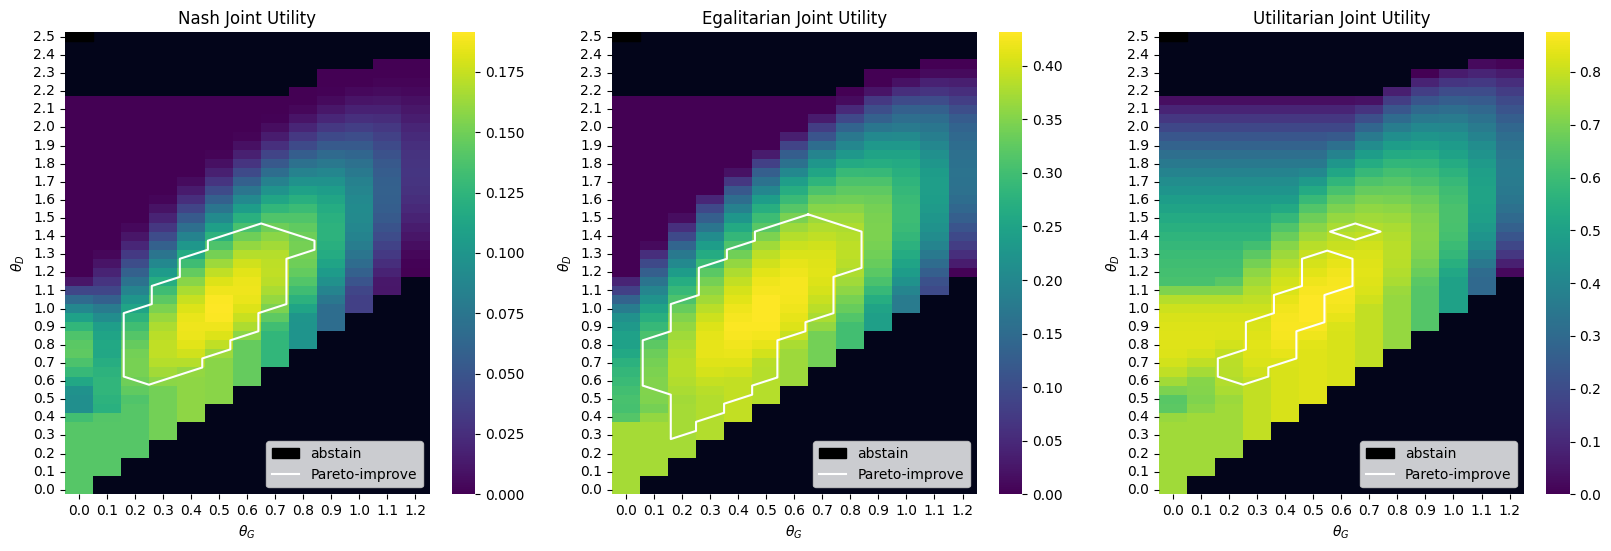

In [568]:
import scipy

# We wish to show where both U_G and U_D improve
fig, ax = plt.subplots(1,3,figsize=(20, 6))

util_pivot_UG = results_dataset_util.pivot_table(values='U_G', index='theta', columns='thetaG', aggfunc='mean')
egal_pivot_UG = results_dataset_egal.pivot_table(values='U_G', index='theta', columns='thetaG', aggfunc='mean')
nash_pivot_UG = results_dataset_nash.pivot_table(values='U_G', index='theta', columns='thetaG', aggfunc='mean')

# What is the value of beta_1 at theta = 0 and thetaG = 0 for the utilitarian, nash and egalitarian utilities
util_UG_noreg = util_pivot_UG.iloc[0,0]#results_dataset[(results_dataset['theta'] == 0) & (results_dataset['thetaG'] == 0)]['beta_1'].values[0]
egal_UG_noreg = egal_pivot_UG.iloc[0,0]#results_dataset[(results_dataset['theta'] == 0) & (results_dataset['thetaG'] == 0)]['beta_1'].values[0]
nash_UG_noreg = nash_pivot_UG.iloc[0,0]#results_dataset[(results_dataset['theta'] == 0) & (results_dataset['thetaG'] == 0)]['beta_1'].values[0]
util_pivot_UG = util_pivot_UG.iloc[::-1]
egal_pivot_UG = egal_pivot_UG.iloc[::-1]
nash_pivot_UG = nash_pivot_UG.iloc[::-1]

util_pivot_UD = results_dataset_util.pivot_table(values='U_D', index='theta', columns='thetaG', aggfunc='mean')
egal_pivot_UD = results_dataset_egal.pivot_table(values='U_D', index='theta', columns='thetaG', aggfunc='mean')
nash_pivot_UD = results_dataset_nash.pivot_table(values='U_D', index='theta', columns='thetaG', aggfunc='mean')

util_UD_noreg = util_pivot_UD.iloc[0,0]#results_dataset[(results_dataset['theta'] == 0) & (results_dataset['thetaG'] == 0)]['beta_1'].values[0]
egal_UD_noreg = egal_pivot_UD.iloc[0,0]#results_dataset[(results_dataset['theta'] == 0) & (results_dataset['thetaG'] == 0)]['beta_1'].values[0]
nash_UD_noreg = nash_pivot_UD.iloc[0,0]#results_dataset[(results_dataset['theta'] == 0) & (results_dataset['thetaG'] == 0)]['beta_1'].values[0]
util_pivot_UD = util_pivot_UD.iloc[::-1]
egal_pivot_UD = egal_pivot_UD.iloc[::-1]
nash_pivot_UD = nash_pivot_UD.iloc[::-1]

util_pivot = results_dataset_util.pivot_table(values='U_util', index='theta', columns='thetaG', aggfunc='mean')
egal_pivot = results_dataset_egal.pivot_table(values='U_egal', index='theta', columns='thetaG', aggfunc='mean')
nash_pivot = results_dataset_nash.pivot_table(values='U_nash', index='theta', columns='thetaG', aggfunc='mean')

# Reverse the y axis for the heatmaps
util_pivot = util_pivot.iloc[::-1]
egal_pivot = egal_pivot.iloc[::-1]
nash_pivot = nash_pivot.iloc[::-1]


sns.heatmap(nash_pivot, ax=ax[0], cmap='viridis', vmin = 0)
ax[0].set_title('Nash Joint Utility')
sns.heatmap(egal_pivot, ax=ax[1], cmap='viridis', vmin = 0)
ax[1].set_title('Egalitarian Joint Utility')
sns.heatmap(util_pivot , ax=ax[2], cmap='viridis', vmin = 0)
ax[2].set_title('Utilitarian Joint Utility')

# Use patch to plot the line where util_pivot_improve is 1
import matplotlib.patches as patches

# Create a mask for the line where util_pivot_improve is 1
mask = util_pivot_improve == 1

# Create a patch for the line
patch = patches.Rectangle((0, 0), 1, 1, fill=False, edgecolor='white', linewidth=1)

# Add the patch to the plot. Color the patch white  
ax[2].add_patch(patch)


# Now, plot a contour map to show where beta_1 is lower than the noreg values
util_pivot_improve = util_pivot.copy()
util_pivot_improve[(util_pivot_UG > util_UG_noreg)&(util_pivot_UD > util_UD_noreg)]=1
util_pivot_improve[(util_pivot_UG <= util_UG_noreg)|(util_pivot_UD <= util_UD_noreg)]=0
util_pivot_abstain = util_pivot.copy()
util_pivot_abstain[(util_pivot<0)|(np.isnan(util_pivot))]=1
util_pivot_abstain[util_pivot>=0]=np.nan
egal_pivot_improve = egal_pivot.copy()
egal_pivot_improve[(egal_pivot_UG > egal_UG_noreg)&(egal_pivot_UD > egal_UD_noreg)]=1
egal_pivot_improve[(egal_pivot_UG <= egal_UG_noreg)|(egal_pivot_UD <= egal_UD_noreg)]=0
egal_pivot_abstain = egal_pivot.copy()
egal_pivot_abstain[(egal_pivot<0)|(np.isnan(egal_pivot))]=1
egal_pivot_abstain[egal_pivot>=0]=np.nan
nash_pivot_improve = nash_pivot.copy()
nash_pivot_improve[(nash_pivot_UG > nash_UG_noreg)&(nash_pivot_UD > nash_UD_noreg)]=1
nash_pivot_improve[(nash_pivot_UG <= nash_UG_noreg)|(nash_pivot_UD <= nash_UD_noreg)]=0
nash_pivot_abstain = nash_pivot.copy()
nash_pivot_abstain[(nash_pivot<0)|(np.isnan(nash_pivot))]=1
nash_pivot_abstain[nash_pivot>=0]=np.nan

# Now plot a contour map to show where both U_G and U_D improve
ax[2].contour(util_pivot_improve, levels=[0.1,1], colors='white', zorder=100)
sns.heatmap(util_pivot_abstain, ax=ax[2], cbar=False,label='abstain')
ax[2].fill([0,0,1,1],[0,1,1,0],color='black', label='abstain')
ax[2].plot([],[],color='white', label='Pareto-improve')
ax[2].legend(loc='lower right')
ax[2].set_xlabel('$\\theta_G$')
ax[2].set_ylabel('$\\theta_D$')

# Plot the full contour - circumnavigate!

# Get the points and vertices of the contour
# Get the contour and extract its vertices
contour_set = ax[1].contourf(egal_pivot_improve, levels=[0.1,1], colors='white', zorder=100, linewidths=0,alpha=0)

# Extract the contour paths
contour_paths = []
for collection in contour_set.collections:
    for path in collection.get_paths():
        vertices = path.vertices
        contour_paths.append(vertices)
        print(f"Contour path with {len(vertices)} vertices:")
        print(vertices)

# Add the last point to the beginning of the list
contour_paths[0] = np.vstack((contour_paths[0][-1], contour_paths[0]))

# Plot the contour paths
ax[1].plot(contour_paths[0][:,0], contour_paths[0][:,1], color='white')
#ax[0].contour(egal_pivot_improve, levels=[0.1,1], colors='white', zorder=100, linewidths=5)
sns.heatmap(egal_pivot_abstain, ax=ax[1], cbar=False,label='abstain')
ax[1].fill([0,0,1,1],[0,1,1,0],color='black', label='abstain')
ax[1].plot([],[],color='white', label='Pareto-improve')
ax[1].legend(loc='lower right')
ax[1].set_xlabel('$\\theta_G$')
ax[1].set_ylabel('$\\theta_D$')

ax[0].contour(nash_pivot_improve, levels=[0.1,1], colors='white', zorder=100)
sns.heatmap(nash_pivot_abstain, ax=ax[0], cbar=False,label='abstain')
ax[0].fill([0,0,1,1],[0,1,1,0],color='black', label='abstain')
ax[0].plot([],[],color='white', label='Pareto-improve')
ax[0].legend(loc='lower right')
ax[0].set_xlabel('$\\theta_G$')
ax[0].set_ylabel('$\\theta_D$')


#plt.savefig('joint_util_heatmaps_june4.png', bbox_inches='tight', dpi=300)


/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_81622/1062017990.py:34: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax[0].legend(loc='upper left')


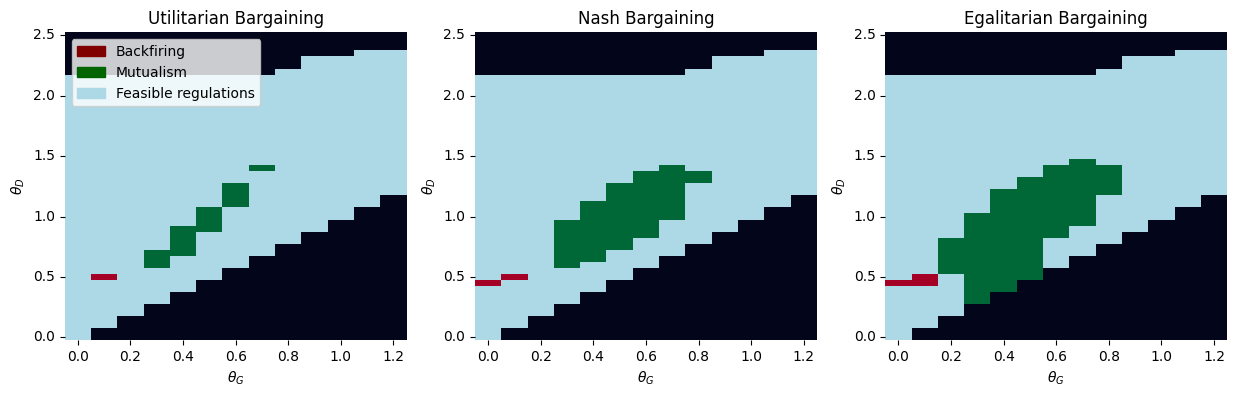

In [589]:
# Reproduce the plots above but with just the abstain/not abstain regions
fig, ax = plt.subplots(1,3,figsize=(15, 4))

# Set solid lightblue background for all subplots
for i in range(3):
    ax[i].set_facecolor('lightblue')


upi_array = np.array(util_pivot_improve)
upi_array[upi_array == 0] = np.nan
sns.heatmap(upi_array, cbar=False, cmap='RdYlGn_r', ax=ax[0])
upb = np.array(util_pivot_backfire)
upb[upb==0]=np.nan
sns.heatmap(upb, cbar=False, cmap='RdYlGn', ax=ax[0],label='HI')


npi_array = np.array(nash_pivot_improve)
npi_array[npi_array == 0] = np.nan
sns.heatmap(npi_array, cbar=False, cmap='RdYlGn_r', ax=ax[1])

npb = np.array(nash_pivot_backfire)
npb[npb==0]=np.nan
sns.heatmap(npb, cbar=False, cmap='RdYlGn', ax=ax[1])

epi_array = np.array(egal_pivot_improve)
epi_array[epi_array == 0] = np.nan
sns.heatmap(epi_array, cbar=False, cmap='RdYlGn_r', ax=ax[2])
epb = np.array(egal_pivot_backfire)
epb[epb==0]=np.nan
sns.heatmap(epb, cbar=False, cmap='RdYlGn', ax=ax[2], label='hi')
ax[0].fill([],[],c='maroon',label='Backfiring')
ax[0].fill([],[],c='darkgreen',label='Mutualism')
ax[0].fill([],[],c='lightblue',label='Feasible regulations')
ax[0].legend(loc='upper left')
#ax[1].legend()

#Draw a horizontal line at theta = 0.499
#ax[0].scatter([0.5],[41], c='maroon',linewidth=2)
#ax[1].scatter([0.5],[41], c='maroon',linewidth=2)
#ax[0].scatter([0.5],[41], c='maroon',linewidth=2, label = 'Backfiring observed at $\\theta_D=0.5-\\epsilon$')
#ax[0].legend(loc='lower right')
#ax[1].plot([0,1.96],[41,41], c='maroon',linewidth=2)
#ax[2].plot([0,1.96],[41,41], c='maroon',linewidth=2)

sns.heatmap(util_pivot_abstain, ax=ax[2], cbar=False,label='abstain', xticklabels=2, yticklabels=10)
sns.heatmap(egal_pivot_abstain, ax=ax[1], cbar=False,label='abstain', xticklabels=2, yticklabels=10)
sns.heatmap(nash_pivot_abstain, ax = ax[0], cbar=False,label='abstain', xticklabels=2, yticklabels=10)

# Rotate the y axis labels
ax[0].set_yticklabels(ax[0].get_yticklabels(), rotation=0)
ax[1].set_yticklabels(ax[1].get_yticklabels(), rotation=0)
ax[2].set_yticklabels(ax[2].get_yticklabels(), rotation=0)
ax[0].set_xlabel("$\\theta_G$")
ax[1].set_xlabel("$\\theta_G$")
ax[2].set_xlabel("$\\theta_G$")
ax[0].set_ylabel("$\\theta_D$")
ax[1].set_ylabel("$\\theta_D$")
ax[2].set_ylabel("$\\theta_D$")

ax[0].set_title('Utilitarian Bargaining')
ax[1].set_title('Nash Bargaining')
ax[2].set_title('Egalitarian Bargaining')

plt.savefig('phase_diagrams_with_bargaining_june9.png', dpi=300, bbox_inches='tight')

In [595]:
results_with_bargaining = results_dataset.copy()

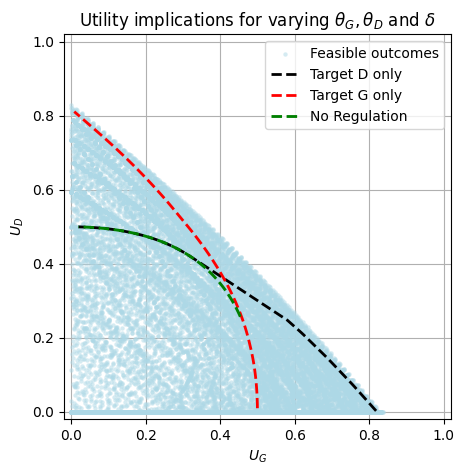

In [651]:
from scipy.spatial import ConvexHull

fix,ax = plt.subplots(1,1,figsize=[5,5])

plt.grid()

sns.scatterplot(data=results_with_bargaining,x='U_G',y='U_D',alpha=.5,color='lightblue',label='Feasible outcomes',linewidth=0,zorder=2,s=10) # utility implications \nover $(\\theta_G,\\theta_D,\\delta)$
#sns.scatterplot(data=results_with_bargaining[(results_with_bargaining['thetaG']==0)],x='U_G',y='U_D',alpha=1,label='Feasible utility implications over $\\delta,\\theta_D$',linewidth=0)
#sns.scatterplot(data=results_with_bargaining[(results_with_bargaining['theta']==results_with_bargaining['thetaG'])],x='U_G',y='U_D',alpha=1,label='Feasible utility implications over $\\delta,\\theta_G$',linewidth=0)
#sns.scatterplot(data=results_with_bargaining[(results_with_bargaining['theta']==0)&(results_with_bargaining['thetaG']==0)],x='U_G',y='U_D',alpha=1,label='Feasible utility implications over $\\delta$ in anarchy',linewidth=0)
#sns.scatterplot(data=results_with_bargaining[np.multiply(results_with_bargaining['U_G'],results_with_bargaining['U_D'])==np.max(np.multiply(results_with_bargaining['U_G'],results_with_bargaining['U_D']))],x='U_G',y='U_D',color='red',label="Bargaining Solution")


plot_hull_data = results_with_bargaining.loc[(results_with_bargaining['thetaG']==0)&(results_with_bargaining['U_G']>=0),['U_G','U_D']].reset_index(drop=True)
G_convhull = ConvexHull(results_with_bargaining.loc[results_with_bargaining['thetaG']==0,['U_G','U_D']])
# Compute Pareto frontier instead of convex hull

# For Target D only case
plot_hull_data = results_with_bargaining.loc[(results_with_bargaining['thetaG']==0)&(results_with_bargaining['U_G']>=0),['U_G','U_D']].reset_index(drop=True)
plt.plot(plot_hull_data.iloc[G_convhull.vertices[3:],0], plot_hull_data.iloc[G_convhull.vertices[3:],1],linestyle='--',color='black',lw=2,label='Target D only',zorder=10)

plot_hull_data = results_with_bargaining.loc[(results_with_bargaining['theta']==results_with_bargaining['thetaG'])&(results_with_bargaining['U_G']>=0),['U_G','U_D']].reset_index(drop=True)
G_convhull = ConvexHull(plot_hull_data)
plt.plot(plot_hull_data.iloc[G_convhull.vertices[7:-2],0], plot_hull_data.iloc[G_convhull.vertices[7:-2],1],'r--', lw=2,label='Target G only',zorder=10)

plot_hull_data = results_with_bargaining.loc[(results_with_bargaining['theta']==0)&(results_with_bargaining['thetaG']==0)&(results_with_bargaining['U_G']>=0),['U_G','U_D']].reset_index(drop=True)
G_convhull = ConvexHull(results_with_bargaining.loc[(results_with_bargaining['theta']==0)&(results_with_bargaining['thetaG']==0),['U_G','U_D']])
plt.plot(plot_hull_data.iloc[G_convhull.vertices[8:],0], plot_hull_data.iloc[G_convhull.vertices[8:],1],'g--', lw=2.05,label='No Regulation',zorder=10)

#plot_hull_data = results_with_bargaining.loc[(results_with_bargaining['U_G']>=0),['U_G','U_D']].reset_index(drop=True)
#G_convhull = ConvexHull(results_with_bargaining.loc[results_with_bargaining['U_G']>=0,['U_G','U_D']])
#plt.plot(plot_hull_data.iloc[G_convhull.vertices[9:-1],0], plot_hull_data.iloc[G_convhull.vertices[9:-1],1],'y--', lw=3,label='Target both')

#plt.plot(np.linspace(0,0.83,100),np.linspace(0.83,0,100))
plt.xlim([-0.02,1.02])
plt.ylim([-0.02,1.02])
plt.title("Utility implications for varying $\\theta_G, \\theta_D$ and $\\delta$")
plt.legend(loc = 'upper right') #bbox_to_anchor=[.33,.995])
plt.xlabel("$U_G$")
plt.ylabel("$U_D$")

plt.savefig('multivariate_analysis_pareto_regulation_improves_june10.png',bbox_inches='tight',dpi=300)


In [574]:
results_dataset_util[results_dataset_util['theta']==0.5]

,Unnamed: 0,C0,C1,r,delta,theta,thetaG,alpha_0,alpha_1,beta_1,U_G,U_D,Gstrategy,Dstrategy,beta_0,U_util,U_nash,U_egal
30,1060,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.818247,0.5,0.0,0.409124,0.5,0.500000,0.483483,0.165236,unconstrained,unconstrained,0.409124,0.648719,0.079889,0.165236
31,5831,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.505052,0.5,0.1,0.252526,0.5,0.500000,0.431282,0.273705,$\beta_0=\theta_G$,constrained $\alpha_1=\alpha_0$,0.100000,0.704987,0.118044,0.273705
32,10436,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.494948,0.5,0.2,0.247474,0.5,0.500000,0.393705,0.351282,$\beta_0=\theta_G$,constrained $\alpha_1=\alpha_0$,0.200000,0.744987,0.138302,0.351282
33,14830,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.333299,0.5,0.3,0.166649,0.5,0.633351,0.259973,0.533361,$\beta_0=\theta_G$,unconstrained,0.300000,0.793333,0.138659,0.259973
34,19044,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.333299,0.5,0.4,0.166649,0.5,0.733351,0.223302,0.600031,$\beta_0=\theta_G$,unconstrained,0.400000,0.823333,0.133988,0.223302
35,23062,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.333299,0.5,0.5,0.166649,0.5,0.833351,0.166632,0.666701,$\beta_0=\theta_G$,unconstrained,0.500000,0.833333,0.111094,0.166632


In [329]:
## Let's try computing that one extra game

def U_D(gamma_1,gamma_0,C_1,r,delta):
    return (1-delta)*np.dot(r,gamma_1) - np.dot(np.dot(np.subtract(gamma_1,gamma_0),C_1),np.subtract(gamma_1,gamma_0))

#U_D = term0 * alpha_0 + termA*beta_0^2 + termB&beta_0 + termC
def get_UD_zero_levelset_terms(C_1,r,delta,theta):
    term0 = (1-delta)*r[0]
    termC = ((1-delta)**2/(4*C_1[0,0]) 
             + (1-delta)*r[1]*theta 
             - (C_1[0,1]*(1-delta)*r[0]*theta/C_1[0,0]) 
             + C_1[0,1]**2 * theta**2 / C_1[0,0]
             - C_1[1,1]*theta**2
            )
    termB = (C_1[0,1]*(1-delta)*r[0] / C_1[0,0]
             - 2*C_1[0,1]**2 * theta / C_1[0,0]
             + 2*C_1[1,1]*theta
            )
    termA = (C_1[0,1]**2 / C_1[0,0]
             - C_1[1,1]
            )
    return term0,termA,termB,termC

def D_strategy(gamma_0,C_1,r,delta,theta):
    if sum(np.equal(gamma_0,[-.1,-.1]))==2:
        return np.array([-.1,-.1]),-.1,"abstain"
    #Abstain condition
    alpha_0 = gamma_0[0]
    beta_0 = gamma_0[1]
    #This is the version without cross-terms
    #abstain_quadratic_A = -C_1[1,1]
    #abstain_quadratic_B = (C_1[0,1]*(1-delta)*r[0]/C_1[0,0]) + 2*theta*C_1[1,1]
    #abstain_quadratic_C = ((1-delta)**2 * r[0]**2 / (4*C_1[0,0])) + (1-delta)*r[1]*theta - (C_1[0,1]*(1-delta)*r[0]*theta/C_1[0,0])-C_1[1,1]*theta**2
    #if 0 > ((1-delta)*r[0])*alpha_0 + abstain_quadratic_A*beta_0**2 + abstain_quadratic_B*beta_0 + abstain_quadratic_C:
    #    return [-.1,-.1],"abstain",-0.1
    term0,termA,termB,termC = get_UD_zero_levelset_terms(C_1,r,delta,theta)
    #print(term0*alpha_0 + termA*beta_0**2 + termB*beta_0 + termC)
    if 0 > term0*alpha_0 + termA*beta_0**2 + termB*beta_0 + termC:
        return [-.1,-.1],-0.1,"abstain"
    
    #Closed-form solution
    gamma_candidate_1 = gamma_0 + 0.5 * (1-delta) * np.dot(np.linalg.inv(C_1),r)
    gamma_candidate_2 = np.array([alpha_0,np.max([beta_0+(1-delta)*r[1]/(2*C_1[1,1]),theta])]) #can likely remove the np.max() and theta option from this
    #Making a slight change here to account for cross-terms:
    gamma_candidate_3 = np.array([np.max([alpha_0,
                                          alpha_0+(1-delta)*r[0]/(2*C_1[0,0]) - (C_1[0,1]/C_1[0,0])*(theta-beta_0)]),
                                  np.max([beta_0,theta])
                                 ])
    
    #Omit unconstrained candidate if it is infeasible
    if gamma_candidate_1[0]<alpha_0 or gamma_candidate_1[1]<np.max([beta_0,theta]):
        candidates = [gamma_candidate_2,gamma_candidate_3]
        strategy_list = ['constrained $\\alpha_1=\\alpha_0$','constrained $\\beta_1=max(\\beta_0,\\theta)$']
    else:
        candidates = [gamma_candidate_1,gamma_candidate_2,gamma_candidate_3]
        strategy_list = ['unconstrained', 'constrained $\\alpha_1=\\alpha_0$','constrained $\\beta_1=max(\\beta_0,\\theta)$']
        
    #print(candidates)
    #Strategy list for explaining remaining candidates
    strategies = [strategy_list[i] for i in range(len(candidates))]
    
    #Evaluate utilities for remaining candidates
    utilities = [U_D(candidates[i],gamma_0,C_1,r,delta) for i in range(len(candidates))]
    index_choice = np.argmax(utilities)
    
    return candidates[index_choice], utilities[index_choice], strategies[index_choice]
    
def U_G(gamma_0,C_0,C_1,r,delta,theta):
    return delta*np.dot(r,D_strategy(gamma_0,C_1,r,delta,theta)[0]) - np.dot(np.dot(gamma_0,C_0),gamma_0)

def get_candidates(C_0,C_1,delta,r,theta,thetaG,epsilon=0.000001):
    a, b, l = symbols('a b l',real=True)
    C_0_rat = np.array([[Rational(C_0[0,0]),Rational(C_0[0,1])],[Rational(C_0[1,0]),Rational(C_0[1,1])]])
    C_1_rat = np.array([[Rational(C_1[0,0]),Rational(C_1[0,1])],[Rational(C_1[1,0]),Rational(C_1[1,1])]])
    delta_rat = Rational(delta)#0.5
    theta_rat = Rational(theta)
    thetaG_rat = Rational(thetaG)
    r_rat = np.array([Rational(r[0]),Rational(r[1])])
    equation_1 = delta_rat*r_rat[0] - 2*C_0_rat[0,0]*a - 2*C_0_rat[0,1]*b - l*(1-delta_rat)*r_rat[0]
    equation_2 = (delta_rat*C_1_rat[0,1]*r_rat[0]/C_1_rat[0,0]) - 2*C_0_rat[1,1]*b - 2*C_0_rat[0,1]*a - l*(C_1_rat[0,1]*(1-delta_rat)*r_rat[0]/C_1_rat[0,0] - 2*C_1_rat[0,1]**2 * theta_rat/C_1_rat[0,0] + 2*C_1_rat[1,1]*theta_rat + 2*(C_1_rat[0,1]/C_1_rat[0,0]-C_1_rat[1,1])*b)
    term0,termA,termB,termC = get_UD_zero_levelset_terms(C_1_rat,r_rat,delta_rat,theta_rat)
    equation_3 = term0*a + termA*b**2 + termB*b + termC
    raw_results = solve([equation_1,equation_2,equation_3],[a,b,l],domain=S.Reals)#nonlinsolve([equation_1,equation_2,equation_3],[a,b,l],domain=S.Reals)
    raw_results = list(raw_results)
    #print(Float(raw_results,10))
    #print(np.array(raw_results).shape)
    #print(raw_results[0][0])
    results = []
    for i in range(len(raw_results)):
        if isinstance(raw_results[i][0], complex) or isinstance(raw_results[i][1], complex):
            continue
        if ("I" in str(raw_results[i][0]))or("I" in str(raw_results[i][1])):
            continue
        #if N(raw_results[i][0])>1000 or N(raw_results[i][1])>1000:
        #    print("Very large number.")
        #    continue
        results = results + [np.array([N(raw_results[i][j])+epsilon for j in range(2)])]#[np.add(raw_results[i][:2],epsilon)]#[np.array([N(raw_results[i][j])+epsilon for j in range(2)])]
    #results = [np.add(raw_results[i][:2],epsilon) for i in range(len(raw_results))]
    return results

def G_strategy(C_0,C_1,r,delta,theta,thetaG,epsilon=0.000001):
    candidate_1 = 0.5*delta*np.dot(np.linalg.inv(C_0),r)
    candidate_2 = np.array([0,np.max([delta*r[1]/(2*C_0[1,1]),thetaG])])
    candidate_3 = np.array([np.max([0,delta*r[0]/(2*C_0[0,0]) - (C_0[0,1]/C_0[0,0])*thetaG]),thetaG])
    
    term0,termA,termB,termC = get_UD_zero_levelset_terms(C_1,r,delta,theta)
    candidate_5 = [(-1/term0)*(termA*thetaG**2 + termB*thetaG + termC)+epsilon,thetaG+epsilon]
    candidate_6_beta_options = np.real(np.roots([termA,termB,termC]))
    candidate_6_1 = np.array([0+epsilon,candidate_6_beta_options[0]+epsilon])
    candidate_6_2 = np.array([0+epsilon,candidate_6_beta_options[1]+epsilon])
    candidate_7 = np.array([0,thetaG])

    candidate_4_candidates = get_candidates(C_0,C_1,delta,r,theta,thetaG)
    
    candidates_all = [candidate_1, candidate_2,candidate_3,candidate_5,candidate_6_1,candidate_6_2,candidate_7]+candidate_4_candidates
    strategies_all = ['unconstrained','$\\alpha_0=0$','$\\beta_0=\\theta_G$','$U_D=0, \\beta_0=\\theta_G$','$U_D=0, \\alpha_0=0$','$U_D=0, \\alpha_0=0$','$\\alpha_0=0,\\beta_0=\\theta_G$']+["$U_D=0$"]*len(candidate_4_candidates)
    utilities_all = [U_G(g0,C_0,C_1,r,delta,theta) for g0 in candidates_all]

    #Filter infeasible options going back to front
    i = len(candidates_all)-1
    while i>=0:
        #print(strategies_all)
        #for index in np.linspace(len(candidates_all),0):
        #i = int(index)
        #print(i)
        #-0.0001 > term0*alpha_0 + termA*beta_0**2 + termB*beta_0 + termC: 
        if U_D(D_strategy(candidates_all[i],C_1,r,delta,theta)[0],candidates_all[i],C_1,r,delta)< 0:
            candidates_all.pop(i)
            strategies_all.pop(i)
            utilities_all.pop(i)
            #continue
        elif U_G(candidates_all[i],C_0,C_1,r,delta,theta)< 0:
            candidates_all.pop(i)
            strategies_all.pop(i)
            utilities_all.pop(i)
            #continue
        elif (candidates_all[i][0]<0)|(candidates_all[i][1]<thetaG):
            candidates_all.pop(i)
            strategies_all.pop(i)
            utilities_all.pop(i)
            #continue
        i = i-1
    
    if len(candidates_all)<=0:
        return np.array([-.1,-.1]),-.1,"abstain"
    
    choice = np.argmax(utilities_all)
    
    if candidates_all[choice][0]<=0:
        print("Strange case: ")
        print(C_0,C_1,r,delta,theta,thetaG)
        print("Choice: ",candidates_all[choice], utilities_all[choice], strategies_all[choice])
        print("All candidates: ",candidates_all)
        print("All utilities: ",utilities_all)
        print("All strategies: ",strategies_all)
        print("D response and utility: ",D_strategy(candidates_all[i],C_1,r,delta,theta))
    
    return candidates_all[choice], utilities_all[choice], strategies_all[choice]

In [483]:
C_0 = np.array([[1,0],[0,1]])
C_1 = np.array([[1,0],[0,1]])
delta = 0.5
theta = .49999 #1.5
thetaG = 0
r = np.array([1,1])

In [484]:
deltas = np.linspace(0.01,0.99, 98)
index = len(results_dataset)

results_with_bargaining = pd.DataFrame(columns=['C0','C1','r','delta','theta','thetaG','alpha_0','alpha_1','beta_1','U_G','U_D','Gstrategy','Dstrategy'])
results_with_bargaining.iloc[:,:index]= results_dataset

for d in deltas:
    print("Delta: ",d)
    gamma_0, UG, strategyG = G_strategy(C_0,C_1,r,d,theta,thetaG)
    gamma_1, UD, strategyD = D_strategy(gamma_0,C_1,r,d,theta)
    alpha_0 = gamma_0[0]
    beta_0 = gamma_0[1]
    alpha_1 = gamma_1[0]
    beta_1 = gamma_1[1]
    results_with_bargaining.at[index,'C0']=str(C_0)
    results_with_bargaining.at[index,'C1']=str(C_1)
    results_with_bargaining.at[index,'r']=str(r)
    results_with_bargaining.at[index,'delta']=d
    results_with_bargaining.at[index,'theta']=theta
    results_with_bargaining.at[index,'thetaG']=thetaG
    results_with_bargaining.at[index,'alpha_0']=float(alpha_0)
    results_with_bargaining.at[index,'beta_0']=float(beta_0)
    results_with_bargaining.at[index,'alpha_1']=float(alpha_1)
    results_with_bargaining.at[index,'beta_1']=float(beta_1)
    results_with_bargaining.at[index,'U_G']=float(UG)
    results_with_bargaining.at[index,'U_D']=float(UD)
    results_with_bargaining.at[index,'Gstrategy']=strategyG
    results_with_bargaining.at[index,'Dstrategy']=strategyD
    index = index + 1

Delta:  0.01


/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_81622/4003650705.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[[1 0]
 [0 1]]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  results_with_bargaining.at[index,'C0']=str(C_0)


Delta:  0.020103092783505153
Delta:  0.03020618556701031
Delta:  0.04030927835051546
Delta:  0.05041237113402062
Delta:  0.060515463917525776
Delta:  0.07061855670103093
Delta:  0.08072164948453607
Delta:  0.09082474226804123
Delta:  0.10092783505154639
Delta:  0.11103092783505154
Delta:  0.12113402061855669
Delta:  0.13123711340206184
Delta:  0.141340206185567
Delta:  0.15144329896907216
Delta:  0.16154639175257732
Delta:  0.17164948453608248
Delta:  0.18175257731958763
Delta:  0.1918556701030928
Delta:  0.20195876288659795
Delta:  0.2120618556701031
Delta:  0.22216494845360824
Delta:  0.2322680412371134
Delta:  0.24237113402061855
Delta:  0.2524742268041237
Delta:  0.26257731958762887
Delta:  0.272680412371134
Delta:  0.2827835051546392
Delta:  0.2928865979381443
Delta:  0.3029896907216495
Delta:  0.3130927835051546
Delta:  0.3231958762886598
Delta:  0.33329896907216494
Delta:  0.34340206185567007
Delta:  0.35350515463917526
Delta:  0.3636082474226804
Delta:  0.37371134020618557
Delt

In [485]:
results_with_bargaining.to_csv('results_with_backfiring_all_backup.csv')

In [486]:
new_results = results_with_bargaining.iloc[-98:,:].reset_index(drop=True)
last_new_results = results_with_bargaining.iloc[-98*2:-98,:].reset_index(drop=True)
lastlast_new_results = results_with_bargaining.iloc[-98*3:-98*2,:].reset_index(drop=True)

new_results.to_csv('results_with_backfiring_all_backup_last98.csv')
last_new_results.to_csv('results_with_backfiring_all_backup_lastlast19698.csv')
lastlast_new_results.to_csv('results_with_backfiring_all_backup_lastlastlast588.csv')

In [518]:
new_results

,C0,C1,r,delta,theta,thetaG,alpha_0,alpha_1,beta_1,U_G,U_D,Gstrategy,Dstrategy,beta_0
0,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.01,0.49999,0,0.005,0.5,0.49999,0.009975,0.494975,$\beta_0=\theta_G$,"constrained $\beta_1=max(\beta_0,\theta)$",0.000000
1,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.020103,0.49999,0,0.010052,0.5,0.49999,0.020002,0.489848,$\beta_0=\theta_G$,"constrained $\beta_1=max(\beta_0,\theta)$",0.000000
2,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.030206,0.49999,0,0.015103,0.5,0.49999,0.029978,0.484669,$\beta_0=\theta_G$,"constrained $\beta_1=max(\beta_0,\theta)$",0.000000
3,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.040309,0.49999,0,0.020155,0.5,0.49999,0.039903,0.47944,$\beta_0=\theta_G$,"constrained $\beta_1=max(\beta_0,\theta)$",0.000000
4,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.050412,0.49999,0,0.025206,0.5,0.49999,0.049777,0.474159,$\beta_0=\theta_G$,"constrained $\beta_1=max(\beta_0,\theta)$",0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.949588,0.49999,0,0.474794,0.5,0.5,0.498729,0.049142,unconstrained,unconstrained,0.474794
94,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.959691,0.49999,0,0.479845,0.5,0.5,0.499188,0.039497,unconstrained,unconstrained,0.479845
95,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.969794,0.49999,0,0.484897,0.5,0.5,0.499544,0.02975,unconstrained,unconstrained,0.484897
96,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.979897,0.49999,0,0.489948,0.5,0.5,0.499798,0.019901,unconstrained,unconstrained,0.489948


In [517]:
results_with_bargaining.iloc[-98*2:-98*1,:].copy()['Dstrategy'].value_counts()

Dstrategy
$\beta_0=\theta_G$           72
unconstrained                18
$U_D=0, \beta_0=\theta_G$     8
Name: count, dtype: int64

In [534]:
results_utilitarian = results_with_bargaining[results_with_bargaining['Dstrategy']!='unconstrained'].iloc[-1,:]#.copy()['Gstrategy'].value_counts()